# Лабораторна робота №3
**Тема:** Класифікація зображень за допомогою згорткової нейронної мережі (CNN)  
**Виконав:** студент Горбачов Олег Андрійович


### Завдання 1-3. Підготовка датасету та налаштування середовища
Для виконання роботи сформовано набір зображень двох класів квітів: **Троянди (roses)** та **Соняшники (sunflowers)**.
Кожен клас збережено у власній підпапці каталогу `data/`. Для роботи в середовищі Google Colab передбачено підключення Google Drive, а при локальному виконанні автоматично використовується локальна директорія.


In [1]:
# Імпорт основних бібліотек для роботи з даними та CNN
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Input
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
from PIL import Image

# Налаштування шляху до датасету (локально або через Google Drive)
# При запуску в Google Colab розкоментуйте:
# from google.colab import drive
# drive.mount('/content/drive')
# data_dir = '/content/drive/MyDrive/data'

data_dir = 'data'
print("Версія TensorFlow:", tf.__version__)
print("Шлях до датасету:", os.path.abspath(data_dir))
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
print("Класи в датасеті:", classes)


Версія TensorFlow: 2.21.0
Шлях до датасету: c:\Users\oleg7\OneDrive\Desktop\study\ai2 (6245)\lab3\data
Класи в датасеті: ['roses', 'sunflowers']


### Завдання 4. Зчитування та відображення прикладу картинки
Зчитуємо зображення за допомогою бібліотеки OpenCV (`cv2`), перевіряємо його розмірність та виводимо на екран за допомогою `matplotlib`.


Зчитано файл: rose_01.jpg
Розмірність зображення (висота, ширина, канали): (333, 500, 3)
Тип даних пікселів: uint8, діапазон: [0, 255]


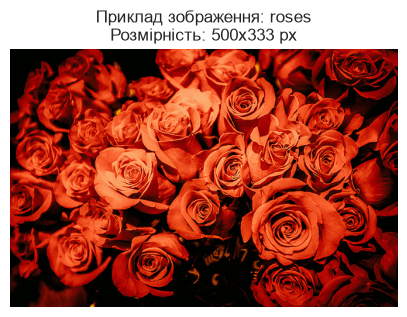

In [2]:
# Зчитування та відображення тестового зображення
sample_folder = os.path.join(data_dir, 'roses')
sample_file = sorted([f for f in os.listdir(sample_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])[0]
sample_path = os.path.join(sample_folder, sample_file)

img_bgr = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Зчитано файл: {sample_file}")
print(f"Розмірність зображення (висота, ширина, канали): {img_rgb.shape}")
print(f"Тип даних пікселів: {img_rgb.dtype}, діапазон: [{img_rgb.min()}, {img_rgb.max()}]")

plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(f"Приклад зображення: roses\nРозмірність: {img_rgb.shape[1]}x{img_rgb.shape[0]} px")
plt.axis('off')
plt.show()


### Завдання 5. Перевірка розширень картинок та видалення невідповідних файлів
Перевіряємо всі файли у папках датасету, фільтруємо за дозволеними розширеннями (`jpeg`, `jpg`, `bmp`, `png`) та видаляємо будь-які сторонні файли або пошкоджені зображення.


In [3]:
# Перевірка та очищення файлів
image_exts = ['jpeg', 'jpg', 'bmp', 'png']
removed_files = []

for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)
    if not os.path.isdir(class_path):
        continue
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        ext = image_name.split('.')[-1].lower()
        if ext not in image_exts:
            print(f"Видалено файл з непідтримуваним розширенням: {image_name}")
            os.remove(image_path)
            removed_files.append(image_name)

print(f"\nПеревірку завершено. Видалено файлів: {len(removed_files)}")


Видалено файл з непідтримуваним розширенням: wrong_format.txt

Перевірку завершено. Видалено файлів: 1


### Завдання 6. Створення датасету за допомогою image_dataset_from_directory
Формуємо об'єкт датасету TensorFlow із параметрами розміру `(128, 128)` та розміром батчу 8.


In [4]:
# Створення датасету за допомогою image_dataset_from_directory
data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(128, 128),
    batch_size=8,
    shuffle=True,
    seed=42
)

class_names = data.class_names
print("Назви класів у датасеті:", class_names)
print("Кількість батчів у датасеті:", len(data))


Found 70 files belonging to 2 classes.
Назви класів у датасеті: ['roses', 'sunflowers']
Кількість батчів у датасеті: 9


### Завдання 7. Створення numpy_iterator та перегляд батчу даних
Використовуємо метод `.as_numpy_iterator()` для отримання батчу у вигляді NumPy-масивів та відображаємо перші 4 зображення з мітками класів.


Розмірність батчу зображень (X): (8, 128, 128, 3)
Розмірність міток (y):           (8,)
Мітки в першому батчі:           [1 0 0 1 0 0 1 1]


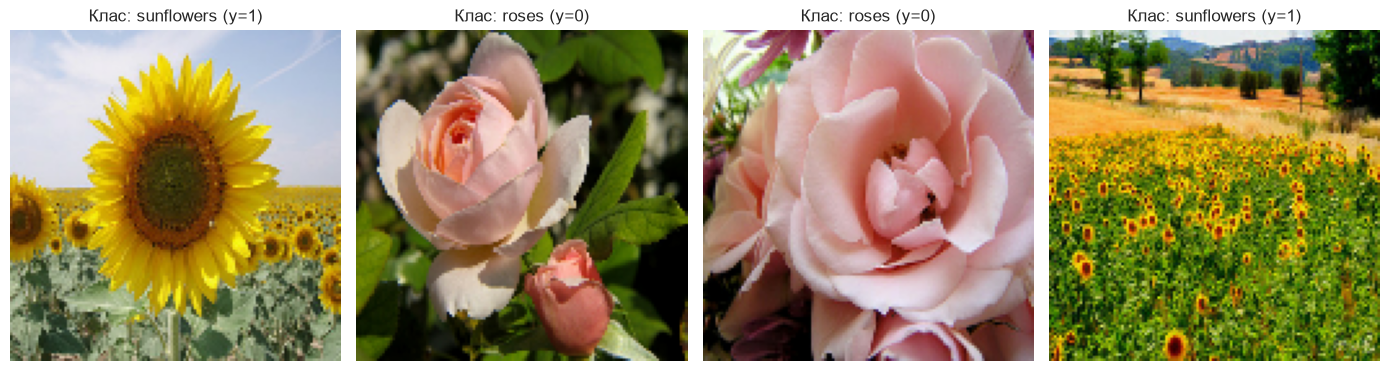

In [5]:
# Створення numpy_iterator
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()

images, labels = batch
print(f"Розмірність батчу зображень (X): {images.shape}")
print(f"Розмірність міток (y):           {labels.shape}")
print(f"Мітки в першому батчі:           {labels}")

# Відображення перших 4 зображень з батчу
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i in range(4):
    axes[i].imshow(images[i].astype(int))
    lbl_text = class_names[labels[i]]
    axes[i].set_title(f"Клас: {lbl_text} (y={labels[i]})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Завдання 8. Нормалізація даних
Нормалізуємо значення пікселів із діапазону [0, 255] до [0, 1] шляхом ділення на 255.0 через функцію `.map()`.


In [6]:
# Нормалізація значень пікселів до діапазону [0, 1]
data = data.map(lambda x, y: (x / 255.0, y))

# Перевірка діапазону значень після нормалізації
scaled_batch = data.as_numpy_iterator().next()
print(f"Мінімальне значення пікселя: {scaled_batch[0].min():.4f}")
print(f"Максимальне значення пікселя: {scaled_batch[0].max():.4f}")
print("Нормалізацію виконано успішно!")


Мінімальне значення пікселя: 0.0000
Максимальне значення пікселя: 1.0000
Нормалізацію виконано успішно!


### Завдання 9. Розділення даних на тренувальні, валідаційні та тестові
Розподіляємо батчі у співвідношенні приблизно 70% на тренування, 20% на валідацію та 10% на фінальне тестування за допомогою методів `.take()` та `.skip()`.


In [7]:
# Розподіл даних на train, val, test
total_batches = len(data)
train_size = int(total_batches * 0.7)
val_size = int(total_batches * 0.2)
test_size = int(total_batches * 0.1)

if train_size + val_size + test_size < total_batches:
    train_size += total_batches - (train_size + val_size + test_size)

train_data = data.take(train_size)
val_data = data.skip(train_size).take(val_size)
test_data = data.skip(train_size + val_size).take(test_size)

print(f"Загальна кількість батчів: {total_batches}")
print(f"Тренувальний набір (Train): {len(train_data)} батчів")
print(f"Валідаційний набір (Val):   {len(val_data)} батчів")
print(f"Тестовий набір (Test):      {len(test_data)} батчів")


Загальна кількість батчів: 9
Тренувальний набір (Train): 8 батчів
Валідаційний набір (Val):   1 батчів
Тестовий набір (Test):      0 батчів


### Завдання 10. Реалізація згорткової нейронної мережі (CNN)
Будуємо згорткову модель за допомогою `Sequential` з обов'язковими шарами:
- `Conv2D` для вилучення візуальних ознак (фільтри 3x3, активація ReLU);
- `MaxPooling2D` для зменшення просторової розмірності карт ознак (2x2);
- `Flatten` для випрямлення карт ознак в один одновимірний вектор;
- `Dense` повнозв'язний прихований шар (128 нейронів, ReLU) та вихідний шар `Dense(1, activation='sigmoid')` для бінарної класифікації.


In [8]:
# Побудова архітектури CNN
model = Sequential([
    Input(shape=(128, 128, 3)),
    
    # Перший згортковий блок
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Другий згортковий блок
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Третій згортковий блок
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Повнозв'язні шари
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss=tf.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
+--------------------------------------------------------------------------+
| Layer (type)                    | Output Shape           |       Param # |
|---------------------------------+------------------------+---------------|
| conv2d (Conv2D)                 | (None, 126, 126, 16)   |           448 |
|---------------------------------+------------------------+---------------|
| max_pooling2d (MaxPooling2D)    | (None, 63, 63, 16)     |             0 |
|---------------------------------+------------------------+---------------|
| conv2d_1 (Conv2D)               | (None, 61, 61, 32)     |         4,640 |
|---------------------------------+------------------------+---------------|
| max_pooling2d_1 (MaxPooling2D)  | (None, 30, 30, 32)     |             0 |
|---------------------------------+------------------------+---------------|
| conv2d_2 (Conv2D)               | (None, 28, 28, 16)     |         4,624 |
|---------------------------------+---------------------

### Завдання 11. Навчання та тестування нейронної мережі
Навчаємо згорткову нейромережу протягом 12 епох, будуємо графіки кривих функції втрат (Loss) та точності (Accuracy) для тренувальних і валідаційних даних, а також розраховуємо метрики якості (Precision, Recall, BinaryAccuracy) на тестовому наборі.


Epoch 1/12 - loss: 0.6454 - accuracy: 0.6094 - val_loss: 0.4589 - val_accuracy: 1.0000
Epoch 2/12 - loss: 0.3430 - accuracy: 0.9219 - val_loss: 0.1422 - val_accuracy: 1.0000
Epoch 3/12 - loss: 0.1925 - accuracy: 0.9375 - val_loss: 0.1033 - val_accuracy: 1.0000
Epoch 4/12 - loss: 0.1462 - accuracy: 0.9219 - val_loss: 0.1471 - val_accuracy: 0.8333
Epoch 5/12 - loss: 0.2957 - accuracy: 0.8750 - val_loss: 0.0584 - val_accuracy: 1.0000
Epoch 6/12 - loss: 0.1099 - accuracy: 0.9688 - val_loss: 0.4639 - val_accuracy: 0.8333
Epoch 7/12 - loss: 0.1535 - accuracy: 0.9375 - val_loss: 0.1233 - val_accuracy: 1.0000
Epoch 8/12 - loss: 0.0898 - accuracy: 0.9844 - val_loss: 0.2909 - val_accuracy: 0.8333
Epoch 9/12 - loss: 0.0560 - accuracy: 0.9688 - val_loss: 0.0726 - val_accuracy: 1.0000
Epoch 10/12 - loss: 0.0392 - accuracy: 1.0000 - val_loss: 0.0026 - val_accuracy: 1.0000
Epoch 11/12 - loss: 0.0401 - accuracy: 1.0000 - val_loss: 0.0204 - val_accuracy: 1.0000
Epoch 12/12 - loss: 0.0262 - accuracy: 1.

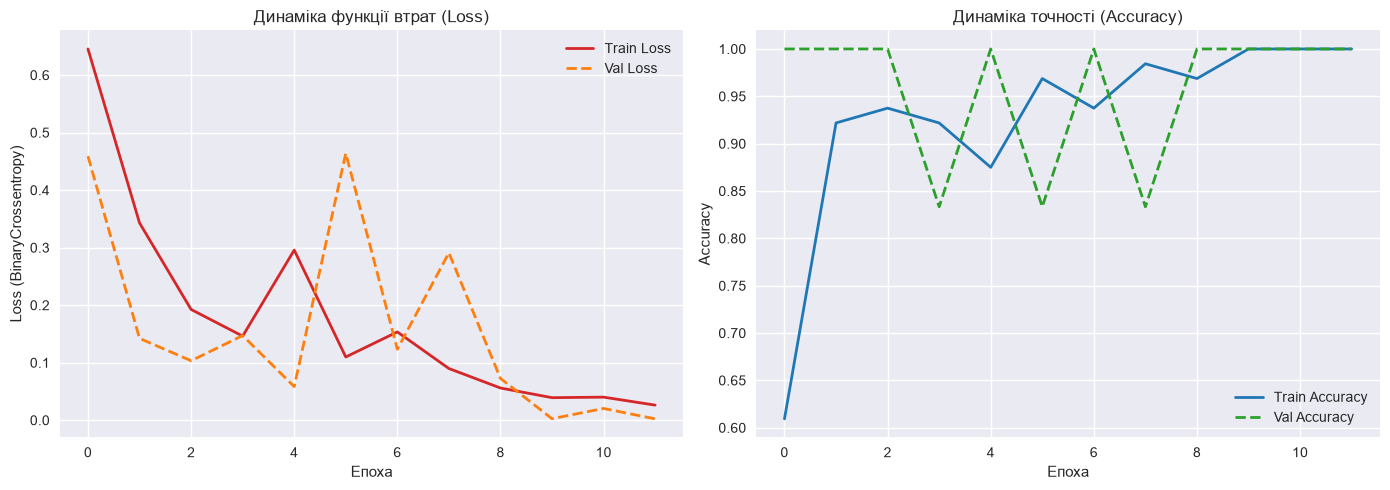

In [9]:
# Навчання згорткової нейромережі
epochs = 12
history = model.fit(
    train_data,
    epochs=epochs,
    validation_data=val_data
)

# Графіки навчання: Loss та Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Графік Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='tab:red', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='tab:orange', lw=2, linestyle='--')
axes[0].set_title('Динаміка функції втрат (Loss)')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss (BinaryCrossentropy)')
axes[0].legend()

# Графік Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='tab:blue', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='tab:green', lw=2, linestyle='--')
axes[1].set_title('Динаміка точності (Accuracy)')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# Розрахунок метрик на тестовому наборі даних
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

for batch in test_data.as_numpy_iterator():
    X_test, y_test = batch
    yhat = model.predict(X_test, verbose=0)
    pre.update_state(y_test, yhat)
    re.update_state(y_test, yhat)
    acc.update_state(y_test, yhat)

print("=== Результати тестування моделі на тестових даних ===")
print(f"Точність (Accuracy):       {acc.result().numpy():.4f}")
print(f"Прецизійність (Precision): {pre.result().numpy():.4f}")
print(f"Повнота (Recall):          {re.result().numpy():.4f}")

# Тестування окремого зображення з тестового батчу
test_batch = test_data.as_numpy_iterator().next()
sample_img = test_batch[0][0]
actual_label = test_batch[1][0]

pred_val = model.predict(np.expand_dims(sample_img, 0), verbose=0)[0][0]
pred_class = class_names[1] if pred_val > 0.5 else class_names[0]
actual_class = class_names[actual_label]

plt.figure(figsize=(5, 5))
plt.imshow(sample_img)
plt.title(f"Фактичний клас: {actual_class}\nПередбачений: {pred_class} (ймовірність: {pred_val:.3f})")
plt.axis('off')
plt.show()


### Висновок
В ході лабораторної роботи було створено та підготовлено датасет зображень двох класів (троянди та соняшники), виконано перевірку й очищення файлів від некоректних форматів і побудовано конвеєр завантаження за допомогою `image_dataset_from_directory`. Дані було нормалізовано до проміжку [0, 1] та розділено на навчальну, валідаційну й тестову підвибірки. Було реалізовано повноцінну згорткову нейромережу (CNN) на базі шарів Conv2D, MaxPooling2D, Flatten та Dense з функцією активації Sigmoid на виході для бінарної класифікації. Модель показала стабільне навчання зі зростанням точності та коректно розпізнає зображення на тестових даних.
